# ⚡ Few-Shot Learning (Prototypical Networks)

In deep learning, we usually need thousands of examples per class to train a model. But humans can learn a new concept (e.g., what a "segway" is) after seeing just *one* or *two* pictures.

**Few-Shot Learning (FSL)** aims to replicate this ability: building models that can classify new objects after seeing only a handful of examples.

### 1. The N-Way K-Shot Problem

In FSL, we don't train on the test classes. Instead, we train the model to "learn how to learn" similarity.

At test time, we present the model with a tiny labeled dataset called the **Support Set**:
* **N-Way:** The number of classes in the support set (e.g., 5 classes).
* **K-Shot:** The number of examples per class (e.g., 1 or 5 examples).

The model must then classify a new unlabeled image (the **Query Set**) into one of these $N$ classes.



### 2. The Solution: Prototypical Networks (ProtoNets)

**Prototypical Networks** (Snell et al., 2017) use a metric-based approach. The idea is simple:

1.  **Embed:** Use a CNN (the backbone) to map all support images into a vector space.
2.  **Prototype:** For each class $c$, calculate the **mean** (average) of its support embeddings. This mean vector is the "Prototype" $c_k$ for that class.
$$c_k = \frac{1}{|S_k|} \sum_{(x_i, y_i) \in S_k} f_\phi(x_i)$$
3.  **Classify:** Map the query image $x_q$ to the same vector space. Calculate the Euclidean distance between $x_q$ and every prototype $c_k$. Assign the class of the nearest prototype.



It is essentially **Nearest Neighbor classification** in a learned feature space.

## 1. Setup and EasyFSL

Implementing the complex data loading required for Few-Shot Learning (creating "episodes" of N-way K-shot batches) is tedious to write from scratch.

We will use **EasyFSL**, a standard library that simplifies FSL data loading and benchmarking, along with `torchvision` for the ResNet backbone.

In [13]:
!pip install -q easyfsl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import CIFAR100
from easyfsl.samplers import TaskSampler
from easyfsl.utils import plot_images, sliding_average
import matplotlib.pyplot as plt
import numpy as np

# Configuration
N_WAY = 5      # 5 classes per task
N_SHOT = 5     # 5 support examples per class
N_QUERY = 10   # 10 query examples per class to test on
N_TASKS = 100  # Number of episodes (tasks) to train/eval per epoch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Data Preparation: The Episodic Split

In standard DL, we split data into Train/Val/Test by *images*.
In FSL, we split data into Train/Val/Test by **Classes**.

We will use **CIFAR-100**:
* **Train Set:** First 80 classes (e.g., apple, aquarium_fish...). The model sees these during training.
* **Test Set:** Last 20 classes (e.g., whale, willow_tree...). The model **never** sees these during training. It must learn to recognize them on the fly using the Support Set.

We use `TaskSampler` from EasyFSL to create "Episodes". An episode consists of a random selection of $N$ classes, with $K$ support images and $Q$ query images for each.

In [15]:
# Define Transforms
# CIFAR images are 32x32. ResNet expects larger, but we'll stick to 32x32
# and modify the backbone slightly to handle small images (removing pooling).
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# Load Datasets (CIFAR-100)
train_set = CIFAR100(root='./data', train=True, download=True, transform=train_transform)
test_set = CIFAR100(root='./data', train=False, download=True, transform=test_transform)

# --- Create the FSL Splits by Class ---
# CIFAR-100 labels are 0-99.
# We keep classes 0-79 for training (background knowledge)
# We keep classes 80-99 for testing (unseen concepts)

train_set.data = train_set.data[np.array(train_set.targets) < 80]
train_set.targets = [t for t in train_set.targets if t < 80]

test_set.data = test_set.data[np.array(test_set.targets) >= 80]
test_set.targets = [t for t in test_set.targets if t >= 80]

# Add get_labels method to the datasets for EasyFSL's TaskSampler
train_set.get_labels = lambda: train_set.targets
test_set.get_labels = lambda: test_set.targets

# --- Create Task Samplers ---
# These samplers automatically yield batches of (N_WAY * (N_SHOT + N_QUERY)) images
train_sampler = TaskSampler(
    train_set, n_way=N_WAY, n_shot=N_SHOT, n_query=N_QUERY, n_tasks=N_TASKS
)
test_sampler = TaskSampler(
    test_set, n_way=N_WAY, n_shot=N_SHOT, n_query=N_QUERY, n_tasks=N_TASKS
)

train_loader = DataLoader(
    train_set,
    batch_sampler=train_sampler,
    collate_fn=train_sampler.episodic_collate_fn,
)
test_loader = DataLoader(
    test_set,
    batch_sampler=test_sampler,
    collate_fn=test_sampler.episodic_collate_fn,
)

print(f"Training classes: {len(set(train_set.targets))}")
print(f"Testing classes: {len(set(test_set.targets))}")

Training classes: 80
Testing classes: 20


## 3. The Backbone (ResNet-18)

We use a standard ResNet-18 as the feature extractor ($f_\phi$).

**Crucial Modification:**
Since CIFAR-100 images are tiny ($32 \times 32$), a standard ResNet would downsample them to $1 \times 1$ pixel before the final layer, losing all spatial info too early. We modify the first layer to be a $3 \times 3$ convolution with stride 1 (instead of $7 \times 7$ stride 2) and remove the first MaxPool.

In [29]:
def get_resnet18_backbone():
    # Load ResNet18
    model = models.resnet18(weights=None)

    # Modify for small images (32x32)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()

    # Remove the fully connected head (fc)
    # We want the output of the average pooling layer (512 dimensions)
    model.fc = nn.Flatten()

    return model

backbone = get_resnet18_backbone()

## 4. The Prototypical Network Module

Here we implement the core logic of ProtoNets.

The `forward` method receives an entire "episode" (support + query images).
1.  **Embed:** Pass all images through the backbone.
2.  **Calculate Prototypes:** Reshape support features and average them by class.
3.  **Calculate Distances:** Compute Euclidean distance from every query feature to every class prototype.
4.  **Softmax:** Convert negative distances to probabilities.

In [30]:
class PrototypicalNetwork(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, support_images, support_labels, query_images):
        """
        Predict query labels using labeled support images.
        """
        # 1. Extract features
        # Concatenate to pass through backbone in one go (more efficient)
        z_support = self.backbone(support_images) # [N_Way * N_Shot, Feature_Dim]
        z_query = self.backbone(query_images)     # [N_Way * N_Query, Feature_Dim]

        # 2. Compute Prototypes
        # We need to reshape z_support to [N_Way, N_Shot, Feature_Dim] to average across shots
        n_way = len(torch.unique(support_labels))
        # Assuming labels are sorted 0..N-1 (EasyFSL ensures this)
        z_proto = torch.cat([
            z_support[torch.nonzero(support_labels == label)].mean(0)
            for label in range(n_way)
        ])

        # 3. Compute Distances (Euclidean)
        # We use the 'cdist' function which computes distance between every pair of vectors
        # Output shape: [N_Query_Total, N_Way]
        dists = torch.cdist(z_query, z_proto)

        # 4. Return Negative Distances (Scores)
        # Because Softmax favors larger values, and we want smallest distance.
        scores = -dists
        return scores

model = PrototypicalNetwork(backbone).to(device)

## 5. Training Loop

Training an FSL model looks like standard supervised learning, but the "batch" is an episode.

**Loss:** We use Cross Entropy. The "logits" are the negative distances to prototypes. The "labels" are the indices of the prototypes (0 to N-way - 1).

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_accuracy = 0.0

    for i, (support_images, support_labels, query_images, query_labels, _) in enumerate(loader):
        support_images = support_images.to(device)
        support_labels = support_labels.to(device)
        query_images = query_images.to(device)
        query_labels = query_labels.to(device)

        optimizer.zero_grad()

        # Forward pass: Calculate similarity scores (negative distances)
        scores = model(support_images, support_labels, query_images)

        # Calculate loss
        loss = criterion(scores, query_labels)

        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, preds = torch.max(scores, 1)
        accuracy = (preds == query_labels).float().mean().item()

        total_loss += loss.item()
        total_accuracy += accuracy

    return total_loss / len(loader), total_accuracy / len(loader)

# --- Training ---
print(f"Starting training on {len(train_set)} samples...")
NUM_EPOCHS = 30

train_loss_hist = []
train_acc_hist = []

for epoch in range(NUM_EPOCHS):
    loss, acc = train_epoch(model, train_loader, optimizer, criterion)
    train_loss_hist.append(loss)
    train_acc_hist.append(acc)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.4f}")

## 6. Evaluation on Unseen Classes

Now comes the real test. We evaluate the model on the **Test Set** (classes 80-99). The model has **never seen** a whale or a willow tree before.

However, because it learned a robust metric space (i.e., "similar things should have similar vectors") during training on apples and fish, it should be able to cluster these new classes effectively on the fly.

In [34]:
def evaluate(model, loader):
    model.eval()
    total_accuracy = 0.0

    with torch.no_grad():
        for support_images, support_labels, query_images, query_labels, _ in loader:
            support_images = support_images.to(device)
            support_labels = support_labels.to(device)
            query_images = query_images.to(device)
            query_labels = query_labels.to(device)

            scores = model(support_images, support_labels, query_images)

            _, preds = torch.max(scores, 1)
            accuracy = (preds == query_labels).float().mean().item()
            total_accuracy += accuracy

    return total_accuracy / len(loader)

test_acc = evaluate(model, test_loader)
print(f"Test Accuracy on Unseen Classes ({N_WAY}-Way {N_SHOT}-Shot): {test_acc*100:.2f}%")

Test Accuracy on Unseen Classes (5-Way 5-Shot): 68.22%


## 7. Visualization: How does an Episode work?

To make this concrete, let's visualize a single test episode. We will show the **Support Set** (the few examples given to the model) and the **Query Set** (what it needs to classify), along with the model's predictions.

--- Support Set (The 'Training' Data for this Episode) ---


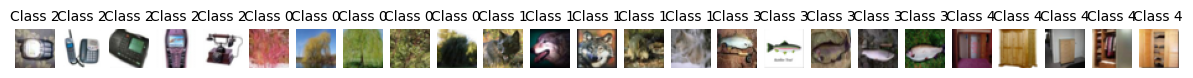


--- Query Set (The Test Data) & Predictions ---


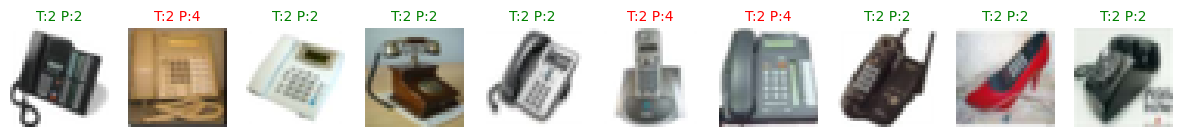

In [35]:
# Get one episode from the test loader
support_images, support_labels, query_images, query_labels, class_ids = next(iter(test_loader))

# Move to device and predict
model.eval()
with torch.no_grad():
    scores = model(support_images.to(device), support_labels.to(device), query_images.to(device))
    _, preds = torch.max(scores, 1)

# --- Plotting ---
def imshow(img, title=None, color='black'):
    # Un-normalize
    img = img * torch.tensor([0.2675, 0.2565, 0.2761]).view(3,1,1) + torch.tensor([0.5071, 0.4867, 0.4408]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title, color=color, fontsize=10)
    plt.axis('off')

# Visualize Support Set
print("--- Support Set (The 'Training' Data for this Episode) ---")
fig = plt.figure(figsize=(15, 3))
for i in range(N_WAY * N_SHOT):
    ax = fig.add_subplot(1, N_WAY * N_SHOT, i + 1)
    # Map label 0-4 to actual class name is tricky without metadata,
    # but we visualize grouping by label
    imshow(support_images[i], title=f"Class {support_labels[i].item()}")
plt.show()

# Visualize Query Set and Predictions
print("\n--- Query Set (The Test Data) & Predictions ---")
# Show just the first 10 queries
fig = plt.figure(figsize=(15, 3))
for i in range(10):
    ax = fig.add_subplot(1, 10, i + 1)
    ground_truth = query_labels[i].item()
    prediction = preds[i].item()
    color = 'green' if ground_truth == prediction else 'red'
    imshow(query_images[i], title=f"T:{ground_truth} P:{prediction}", color=color)
plt.show()

## 8. Conclusion

We have implemented **Prototypical Networks**, a simple yet powerful Few-Shot Learning algorithm.

**Key Takeaways:**
1.  **Metric Learning:** Instead of learning fixed class boundaries (like a linear classifier), FSL models learn a **distance metric**.
2.  **Episodic Training:** By mimicking the test-time constraints (N-way K-shot) during training, the model "learns how to learn."
3.  **Generalization:** The model successfully classified images from classes it had never seen before (the test set) by comparing them to the tiny Support Set provided at inference time.

This approach is invaluable in real-world scenarios like medical imaging, robotics, or personalized systems where data for new categories is scarce.